In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('Cleaned_RBI.csv')
data.head()

,Year,Currency_in_circulation_Total,Other_deposits_with_RBI,Bankers_deposits_with_RBI,Reserve_Money_(Liabilities/Components),RBIs_Claims_on_Government(net),RBIs_Claims_on_Central_Govt,RBIs_Claims_on_Banks_and_Commercial_sector,RBIs_Claims_on_Banks_(Including NABARD),RBIs_claims_on_Commercial_sector_(Excluding NABARD),Net_foreign_exchange_assets_of_RBI,Govts_currency_liabilities_to_the_public,Net_non_monetary_liabilities_of_RBI
0,2001-07-06,234802.0,3980.0,66536.0,305318.0,166691.0,163746.520260,16355.0,7894.0,8461.0,205487.0,5565.0,88780.0
1,2001-07-13,234428.0,3897.0,70531.0,308856.0,166704.0,163762.133695,21772.0,11751.0,10021.0,205354.0,5565.0,90539.0
2,2001-07-20,231389.0,3671.0,69480.0,304540.0,165737.0,162837.728005,19405.0,10148.0,9257.0,205404.0,5565.0,91571.0
3,2001-07-27,227989.0,3517.0,74768.0,306274.0,161554.0,158668.165085,25340.0,13724.0,11616.0,205913.0,5640.0,92173.0
4,2001-08-03,229965.0,3526.0,67139.0,300630.0,164384.0,161507.248330,16081.0,7750.0,8331.0,206301.0,5640.0,91776.0


In [5]:
data['Year'] = pd.to_datetime(data['Year'])

In [7]:
data.set_index('Year', inplace = True)
data.head()

,Currency_in_circulation_Total,Other_deposits_with_RBI,Bankers_deposits_with_RBI,Reserve_Money_(Liabilities/Components),RBIs_Claims_on_Government(net),RBIs_Claims_on_Central_Govt,RBIs_Claims_on_Banks_and_Commercial_sector,RBIs_Claims_on_Banks_(Including NABARD),RBIs_claims_on_Commercial_sector_(Excluding NABARD),Net_foreign_exchange_assets_of_RBI,Govts_currency_liabilities_to_the_public,Net_non_monetary_liabilities_of_RBI
Year,,,,,,,,,,,,
2001-07-06,234802.0,3980.0,66536.0,305318.0,166691.0,163746.520260,16355.0,7894.0,8461.0,205487.0,5565.0,88780.0
2001-07-13,234428.0,3897.0,70531.0,308856.0,166704.0,163762.133695,21772.0,11751.0,10021.0,205354.0,5565.0,90539.0
2001-07-20,231389.0,3671.0,69480.0,304540.0,165737.0,162837.728005,19405.0,10148.0,9257.0,205404.0,5565.0,91571.0
2001-07-27,227989.0,3517.0,74768.0,306274.0,161554.0,158668.165085,25340.0,13724.0,11616.0,205913.0,5640.0,92173.0
2001-08-03,229965.0,3526.0,67139.0,300630.0,164384.0,161507.248330,16081.0,7750.0,8331.0,206301.0,5640.0,91776.0


In [9]:
data.columns

Index(['Currency_in_circulation_Total', 'Other_deposits_with_RBI',
       'Bankers_deposits_with_RBI', 'Reserve_Money_(Liabilities/Components)',
       'RBIs_Claims_on_Government(net)', 'RBIs_Claims_on_Central_Govt',
       'RBIs_Claims_on_Banks_and_Commercial_sector',
       'RBIs_Claims_on_Banks_(Including NABARD)',
       'RBIs_claims_on_Commercial_sector_(Excluding NABARD)',
       'Net_foreign_exchange_assets_of_RBI',
       'Govts_currency_liabilities_to_the_public',
       'Net_non_monetary_liabilities_of_RBI'],
      dtype='object')

## Test for Stationarity:

### 1. Checking Stationarity for Currency in Circulation

In [23]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller Test
adf_test = adfuller(data['Currency_in_circulation_Total'])

print('ADF Test Results')
print(f'ADF Statistic: {round(adf_test[0],3)}')
print(f'p-value: {round(adf_test[1],3)}')
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f' {key}: {round(value,3)}')

ADF Test Results
ADF Statistic: 1.691
p-value: 0.998
Critical Values:
 1%: -3.437
 5%: -2.864
 10%: -2.568


### Conclusion:
The Augmented Dickey-Fuller (ADF) test was conducted on the Currency in Circulation column, yielding a p-value of 0.998, which is significantly greater than the 0.05 significance level. This indicates that the data is non-stationary. Therefore, appropriate transformations are required to make the data stationary for further analysis

In [24]:
# function to perform ADF test:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('P-value:',result[1])
    for key, value in result[4].items():
        print('Critical Value (%s): %0.3f' % (key,value))

In [20]:
Currency = data['Currency_in_circulation_Total']

In [26]:
adf_test(Currency)

ADF Statistic: 1.691267667784823
P-value: 0.998107116295141
Critical Value (1%): -3.437
Critical Value (5%): -2.864
Critical Value (10%): -2.568


In [28]:
import numpy as np
from scipy import stats


# Log Transformation
Currency_log = np.log(Currency)

In [30]:
adf_test(Currency_log)

ADF Statistic: -0.7019014814994358
P-value: 0.8462563963310872
Critical Value (1%): -3.437
Critical Value (5%): -2.864
Critical Value (10%): -2.568


Hence, Log transformation fails to make the data stationary.

In [33]:
# Using a moving average to remove trend

window = 7 # example window size
Currency_ma = Currency.rolling(window = window).mean()
Currency_detrend = Currency - Currency_ma
Currency_detrend = Currency_detrend.dropna()

In [35]:
adf_test(Currency_detrend)

ADF Statistic: -6.991619638598495
P-value: 7.718690351489144e-10
Critical Value (1%): -3.437
Critical Value (5%): -2.864
Critical Value (10%): -2.568


Clearly, Moving Average helps to make the data stationary.

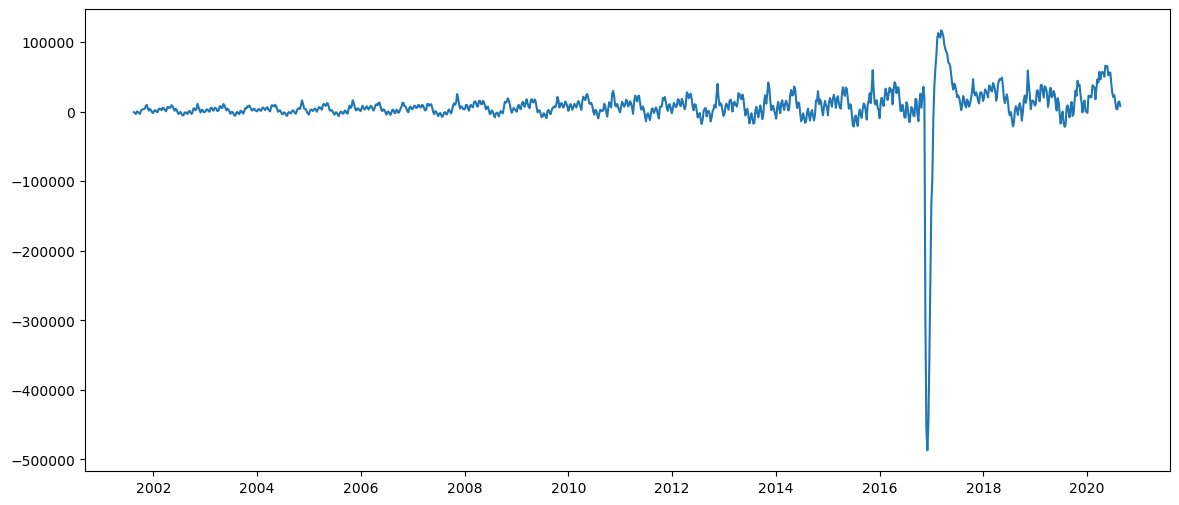

In [70]:
plt.figure(figsize = (14,6))
plt.plot(Currency_detrend)
plt.show()

### 2. Checking Stationarity for Reserve Money

In [26]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller Test
adf_test = adfuller(data['Reserve_Money_(Liabilities/Components)'])

print('ADF Test Results')
print(f'ADF Statistic: {round(adf_test[0],3)}')
print(f'p-value: {round(adf_test[1],3)}')
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f' {key}: {round(value,3)}')

ADF Test Results
ADF Statistic: 1.71
p-value: 0.998
Critical Values:
 1%: -3.437
 5%: -2.864
 10%: -2.568


### Conclusion:
The Augmented Dickey-Fuller (ADF) test was conducted on the Reserve Money column, yielding a p-value of 0.998, which is significantly greater than the 0.05 significance level. This indicates that the data is non-stationary. Therefore, appropriate transformations are required to make the data stationary for further analysis

In [39]:
Reserve_Money = data['Reserve_Money_(Liabilities/Components)']

In [41]:
# Using a moving average to remove trend

window = 7 # example window size
Reserve_Money_ma = Reserve_Money.rolling(window = window).mean()
Reserve_Money_detrend = Reserve_Money - Reserve_Money_ma
Reserve_Money_detrend = Reserve_Money_detrend.dropna()

In [43]:
adf_test(Reserve_Money_detrend)

ADF Statistic: -8.231540649179252
P-value: 6.044267281257822e-13
Critical Value (1%): -3.437
Critical Value (5%): -2.864
Critical Value (10%): -2.568


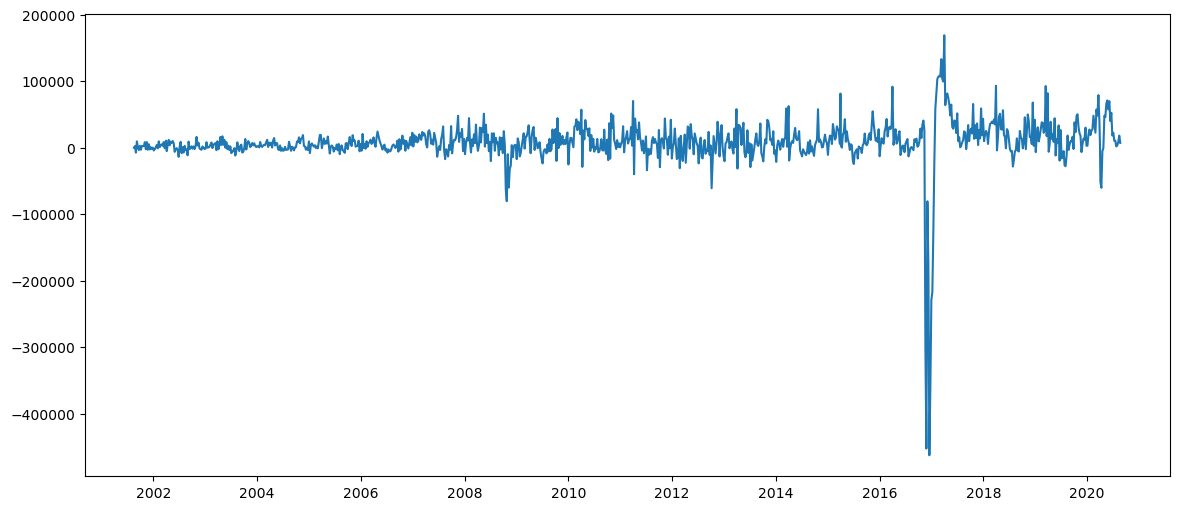

In [66]:
plt.figure(figsize = (14,6))
plt.plot(Reserve_Money_detrend)
plt.show()

Clearly, Moving Average helps to make the data stationary.

### 3. Checking Stationarity for Net Foreign Exchange Assets of RBI

In [29]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller Test
adf_test = adfuller(data['Net_foreign_exchange_assets_of_RBI'])

print('ADF Test Results')
print(f'ADF Statistic: {round(adf_test[0],3)}')
print(f'p-value: {round(adf_test[1],3)}')
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f' {key}: {round(value,3)}')

ADF Test Results
ADF Statistic: 4.226
p-value: 1.0
Critical Values:
 1%: -3.437
 5%: -2.864
 10%: -2.568


### Conclusion:
The Augmented Dickey-Fuller (ADF) test was conducted on the Net foreign exchange assets, yielding a p-value of 1.0, which is significantly greater than the 0.05 significance level. This indicates that the data is non-stationary. Therefore, appropriate transformations are required to make the data stationary for further analysis

In [46]:
Net_foreign = data['Net_foreign_exchange_assets_of_RBI']

In [48]:
# Using a moving average to remove trend

window = 7 # example window size
Net_foreign_ma = Net_foreign.rolling(window = window).mean()
Net_foreign_detrend = Net_foreign - Net_foreign_ma
Net_foreign_detrend = Net_foreign_detrend.dropna()

In [50]:
adf_test(Net_foreign_detrend)

ADF Statistic: -7.744441583842766
P-value: 1.041005036644193e-11
Critical Value (1%): -3.437
Critical Value (5%): -2.864
Critical Value (10%): -2.568


Clearly, Moving Average helps to make the data stationary.

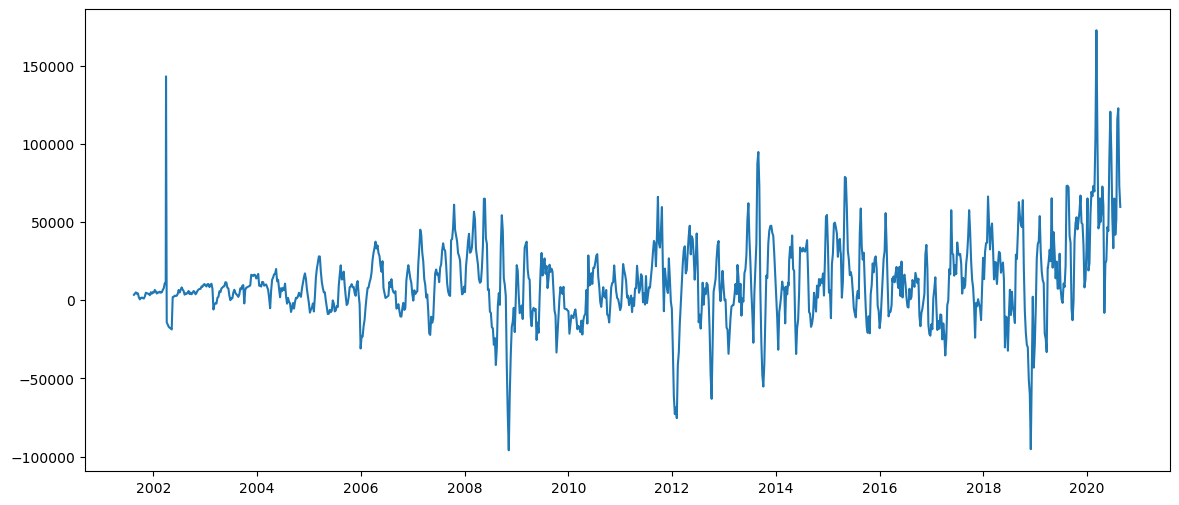

In [68]:
plt.figure(figsize = (14,6))
plt.plot(Net_foreign_detrend)
plt.show()

## Identifying White Noise and Random Walk

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

### 1. Currency in Circulation

In [75]:
# Ljung-Box Test
print("\nLjung-Box Test for Currency in Ciculation:")
lb_test_cc = acorr_ljungbox(Currency_detrend, lags = [10], return_df = True)
print(lb_test_cc)


Ljung-Box Test for Currency in Ciculation:
        lb_stat  lb_pvalue
10  1946.437954        0.0


As the P-value is close to 0. Hence we can colclude that it is a Random Walk.

### 2. Reserve Money

In [80]:
# Ljung-Box Test
print("\nLjung-Box Test for Reserve Money:")
lb_test_rm = acorr_ljungbox(Reserve_Money_detrend, lags = [10], return_df = True)
print(lb_test_rm)


Ljung-Box Test for Reserve Money:
        lb_stat      lb_pvalue
10  1308.393339  5.905789e-275


As the P-value is close to 0. Hence we can colclude that it is a Random Walk.

### 3. Net foreign exchange assets

In [84]:
# Ljung-Box Test
print("\nLjung-Box Test for Net foreign exchange assets:")
lb_test_nfea = acorr_ljungbox(Net_foreign_detrend, lags = [10], return_df = True)
print(lb_test_nfea)


Ljung-Box Test for Net foreign exchange assets:
        lb_stat      lb_pvalue
10  1362.766485  1.083741e-286


As the P-value is close to 0. Hence we can colclude that it is a Random Walk.